# 03. 베이스라인: 처음부터 학습하는 인코더-디코더 Transformer

**작성일**: 2026-09-18

**목표**: 사전학습 가중치를 전혀 쓰지 않고, `dataset/processed/train.csv`만으로 Q→A 응답 생성 Transformer를 처음부터 학습한다. 이 모델의 성능이 04번 노트북의 KoBART 파인튜닝(전이학습)과 비교되는 **베이스라인** 기준점이 된다.

**구조 선택 근거 (인코더-디코더 vs 디코더 전용)**: Q와 A는 성격이 뚜렷이 다른 두 시퀀스이고, "질문 전체를 이해한 뒤 그것을 조건으로 답변을 생성"하는 조건부 생성(conditional generation) 문제다. 이는 기계번역·요약과 동일한 문제 구조이며, 수업 §11(독→영 번역)·§13/§15(BART/T5 요약)에서도 모두 인코더-디코더를 사용했다. 인코더가 Q를 통째로 압축한 표현(memory)을 만들고, 디코더가 그 표현에 cross-attention으로 조건화해 한 토큰씩 A를 생성하는 구조가 이 문제에 자연스럽게 맞는다. (디코더 전용 구조는 Q/A를 하나의 시퀀스로 이어붙여 다음 토큰 예측만으로 학습하는 방식인데, 소스/타겟 경계를 모델이 별도 신호 없이 학습해야 해서 우리처럼 소규모 데이터에는 상대적으로 불리하다고 판단했다.)

**이 노트북이 수업 §11(Seq2Seq Transformer, Multi30k 번역)과 다른 점 및 이유**:
- 소스(Q)와 타겟(A)이 서로 다른 언어가 아니라 같은 한국어이고 02번 노트북에서 학습한 **동일한 BPE vocab**을 공유하므로, 인코더/디코더 임베딩 테이블을 하나로 공유(tie)한다. 파라미터 수를 줄여 소규모 데이터(9,400쌍)에서의 과적합 위험을 낮추기 위함이다.
- 같은 이유로 출력 projection(generator)의 가중치도 임베딩 테이블과 공유한다(weight tying, Press & Wolf 2017 방식) — 파라미터를 더 줄이면서 임베딩-출력 공간의 일관성도 높여준다.
- WMT/Multi30k 같은 대규모 번역 데이터 대비 우리 데이터는 훨씬 작으므로, d_model/layer 수를 강의 예제보다 축소한다(아래 모델 정의 셀에서 근거 설명).

In [1]:
# 2026-09-18: 라이브러리 로드, 데이터/토크나이저 로드, 디바이스 설정
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_df = pd.read_csv('../dataset/processed/train.csv')
val_df = pd.read_csv('../dataset/processed/val.csv')
test_df = pd.read_csv('../dataset/processed/test.csv')

sp = spm.SentencePieceProcessor(model_file='../dataset/processed/chatbot_bpe.model')
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3  # 02번 노트북에서 학습할 때 지정한 special id와 동일하게 맞춤
VOCAB_SIZE = sp.get_piece_size()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '| vocab size:', VOCAB_SIZE)
print(f'train/val/test = {len(train_df)}/{len(val_df)}/{len(test_df)}')

device: cuda | vocab size: 8000
train/val/test = 9400/1175/1175


## 1. 데이터 파이프라인
02번 노트북에서 학습한 BPE 토크나이저로 Q/A를 정수 시퀀스로 바꾸고, 문장 앞뒤에 BOS/EOS를 붙인다. max_length는 01번 노트북에서 배운 것처럼 최댓값이 아니라 **이 코퍼스에서 실제로 측정한 BPE 토큰 길이의 95 percentile**을 기준으로 정한다(이상치 때문에 전체가 과도하게 padding되는 것을 방지).

In [2]:
# 2026-09-18: BPE 토큰 길이 분포를 직접 측정해서 MAX_LEN 근거를 만든다 (01번 노트북과 동일한 방식, 이번엔 서브워드 토큰 기준)
q_token_lens = train_df['Q'].apply(lambda t: len(sp.encode(t, out_type=int)))
a_token_lens = train_df['A'].apply(lambda t: len(sp.encode(t, out_type=int)))

q95 = int(np.percentile(q_token_lens, 95))
a95 = int(np.percentile(a_token_lens, 95))
print(f'Q BPE 토큰 길이 95 percentile: {q95} (최댓값 {q_token_lens.max()})')
print(f'A BPE 토큰 길이 95 percentile: {a95} (최댓값 {a_token_lens.max()})')

# BOS/EOS 2개 토큰 여유를 더하고, GPU 연산 효율을 위해 8의 배수로 올림
MAX_LEN = int(np.ceil((max(q95, a95) + 2) / 8) * 8)
print('MAX_LEN =', MAX_LEN)

Q BPE 토큰 길이 95 percentile: 10 (최댓값 21)
A BPE 토큰 길이 95 percentile: 10 (최댓값 28)
MAX_LEN = 16


In [3]:
# 2026-09-18: 문장 -> [BOS, ...BPE ids..., EOS] 정수 시퀀스 변환 (MAX_LEN 넘으면 자름)
def encode_text(text: str, max_len: int = MAX_LEN):
    ids = sp.encode(text, out_type=int)[: max_len - 2]
    return [BOS_ID] + ids + [EOS_ID]

sample_q = train_df.iloc[0]['Q']
print(sample_q, '->', encode_text(sample_q))

외로워서 그런건지 진짜로 좋아하는 건지 모르겠어요. -> [2, 2040, 6979, 223, 1255, 294, 6983, 61, 1264, 950, 6943, 3]


In [4]:
# 2026-09-18: Q/A pandas DataFrame을 감싸는 Dataset 정의
class ChatbotDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        src = torch.tensor(encode_text(self.questions[idx]), dtype=torch.long)
        tgt = torch.tensor(encode_text(self.answers[idx]), dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    # 배치 안에서 가장 긴 시퀀스에 맞춰서만 패딩(=MAX_LEN 고정 패딩 대비 연산 낭비를 줄임)
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, batch_first=True, padding_value=PAD_ID)
    tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_ID)
    return src_batch, tgt_batch


# BATCH_SIZE=64 선택 근거: 시퀀스가 짧고(MAX_LEN 수십 토큰) 모델도 작아 8GB급 GPU에서 충분히 여유 있게 처리 가능한 크기.
# 너무 작으면 gradient 추정이 노이즈에 민감해지고, 너무 크면 소규모 데이터셋(9,400쌍)에서 파라미터 업데이트 횟수가 줄어든다.
BATCH_SIZE = 64
train_loader = DataLoader(ChatbotDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(ChatbotDataset(val_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

src_ex, tgt_ex = next(iter(train_loader))
print('src batch shape:', src_ex.shape, '| tgt batch shape:', tgt_ex.shape)

src batch shape: torch.Size([64, 14]) | tgt batch shape: torch.Size([64, 15])


## 2. 모델 정의
수업 §11-5(Positional Encoding / Token Embedding / Seq2SeqTransformer)의 구조를 그대로 가져오되, `batch_first=True`로 정리해 배치 축을 다루기 쉽게 하고, 앞서 설명한 대로 임베딩을 인코더/디코더가 공유하도록 수정한다.

In [5]:
# 2026-09-18: 사인/코사인 Positional Encoding (수업 §11-1과 동일한 방식)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.d_model = d_model

    def forward(self, tokens):
        # 임베딩 값에 sqrt(d_model)을 곱해 위치 인코딩과 스케일을 맞춘다 (Vaswani et al., 2017 원 논문 방식)
        return self.embedding(tokens) * math.sqrt(self.d_model)

In [6]:
# 2026-09-18: Seq2Seq Transformer 본체
# Q/A가 같은 언어 + 같은 BPE vocab을 쓰므로 인코더/디코더 임베딩을 하나로 공유(tie)하고,
# 출력 projection(generator)도 임베딩 가중치와 공유(weight tying)해 파라미터 수를 줄인다.
class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.tok_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.generator = nn.Linear(d_model, vocab_size)
        self.generator.weight = self.tok_emb.embedding.weight  # weight tying

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.pos_enc(self.tok_emb(src))
        tgt_emb = self.pos_enc(self.tok_emb(tgt))
        outs = self.transformer(
            src_emb, tgt_emb,
            src_mask=src_mask, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(self.pos_enc(self.tok_emb(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.pos_enc(self.tok_emb(tgt)), memory, tgt_mask)

## 3. 마스크
디코더는 아직 생성하지 않은 미래 토큰을 보면 안 되므로(causal mask), 그리고 인코더/디코더 모두 padding 토큰에 attention이 가지 않도록 두 종류의 마스크를 만든다 (수업 §11-8과 동일한 방식).

In [7]:
# 2026-09-18: causal mask + padding mask 생성 함수
def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)
    return mask


def create_mask(src, tgt, device):
    src_seq_len, tgt_seq_len = src.size(1), tgt.size(1)
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, device)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device)  # 인코더는 문장 전체를 다 볼 수 있어야 하므로 마스킹 없음
    src_padding_mask = (src == PAD_ID)
    tgt_padding_mask = (tgt == PAD_ID)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

## 4. 모델/손실함수/옵티마이저

In [8]:
# 2026-09-18: 하이퍼파라미터와 그 근거
# d_model=256, num_layers=3 (원 논문/수업 예제는 d_model=512, layer=6를 쓰지만, 그건 WMT 수준(수백만 문장) 데이터 기준이다.
#   우리 데이터는 9,400쌍으로 훨씬 작아 그 크기의 모델을 쓰면 파라미터 대비 데이터가 부족해 과적합·비효율 학습 위험이 크다.
#   d_model을 절반, layer 수를 절반으로 줄여 데이터 규모에 맞는 용량으로 조정했다.
# nhead=8: d_model=256을 8등분하면 head당 32차원으로, 원 논문 비율(512/8=64)의 절반 수준으로 head_dim을 유지하는 자연스러운 선택.
# dim_feedforward=512: 관례적으로 d_model의 2배 (원 논문은 4배(2048/512)지만, 역시 모델 규모를 줄인 만큼 비례 축소).
# dropout=0.1: 원 Transformer 논문의 기본값, 정규화를 위해 그대로 채택.
D_MODEL = 256
NHEAD = 8
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
DIM_FEEDFORWARD = 512
DROPOUT = 0.1

model = Seq2SeqTransformer(
    VOCAB_SIZE, D_MODEL, NHEAD, NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, DIM_FEEDFORWARD, DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'학습 가능 파라미터 수: {n_params:,}')

학습 가능 파라미터 수: 6,010,688


In [9]:
# 2026-09-18: 손실함수/옵티마이저
# label_smoothing=0.1: 생성 태스크에서 모델이 정답 토큰 하나에 과도하게 확신(overconfident)하지 않도록 하는 표준적인 정규화 기법
#   (짧은 챗봇 응답 데이터는 유사한 표현이 많아 과확신 시 다양성이 떨어진 응답만 생성하는 문제가 생기기 쉽다).
# ignore_index=PAD_ID: padding 위치는 손실 계산에서 제외.
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)

# Adam, lr=1e-4: 수업 §11-6과 동일한 표준 설정. Transformer는 학습 초반 loss가 불안정할 수 있어 큰 lr보다 안정적인 1e-4를 사용.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)

## 5. 학습
Early stopping(patience=5): 데이터가 작아 과적합이 빠르게 시작될 수 있으므로, validation loss가 5 epoch 연속 개선되지 않으면 학습을 멈추고 가장 좋았던 시점의 가중치를 사용한다.

In [10]:
# 2026-09-18: 1 epoch 학습/평가 함수
def train_epoch(model, dataloader):
    model.train()
    total_loss = 0.0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, device)
        logits = model(src, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, src_padding_mask)

        optimizer.zero_grad()
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 학습 초반 gradient 폭주 방지
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input, device)
        logits = model(src, tgt_input, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, src_padding_mask)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [11]:
# 2026-09-18: 학습 루프 (early stopping, best checkpoint 저장)
MAX_EPOCHS = 30
PATIENCE = 5

ckpt_dir = Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)
ckpt_path = ckpt_dir / 'baseline_transformer.pt'

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()
    train_loss = train_epoch(model, train_loader)
    val_loss = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    elapsed = time.time() - start
    print(f'epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | {elapsed:.1f}s')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'-> validation loss가 {PATIENCE} epoch 연속 개선되지 않아 조기 종료 (best val_loss={best_val_loss:.4f})')
            break

model.load_state_dict(torch.load(ckpt_path, map_location=device))
print('best checkpoint 로드 완료:', ckpt_path)

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch 01 | train_loss 29.8223 | val_loss 21.7803 | 16.3s


epoch 02 | train_loss 22.5286 | val_loss 19.3048 | 22.5s


epoch 03 | train_loss 19.6302 | val_loss 16.7143 | 17.2s


epoch 04 | train_loss 17.4353 | val_loss 14.8297 | 14.3s


...

epoch 26 | train_loss 6.6514 | val_loss 6.5183 | 12.9s


epoch 27 | train_loss 6.5563 | val_loss 6.4573 | 13.2s


epoch 28 | train_loss 6.4740 | val_loss 6.4413 | 12.4s


epoch 29 | train_loss 6.4072 | val_loss 6.4135 | 14.2s


epoch 30 | train_loss 6.3332 | val_loss 6.3724 | 11.5s
best checkpoint 로드 완료: ..\checkpoints\baseline_transformer.pt


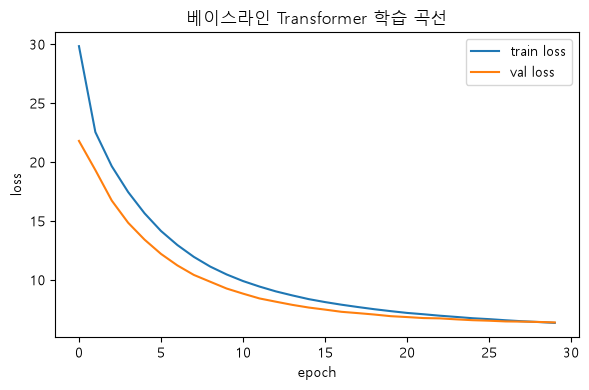

In [12]:
# 2026-09-18: 학습/검증 loss curve
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history['train_loss'], label='train loss')
ax.plot(history['val_loss'], label='val loss')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.set_title('베이스라인 Transformer 학습 곡선')
ax.legend()
plt.tight_layout()
plt.savefig('../dataset/processed/baseline_loss_curve.png', dpi=120)
plt.show()

## 6. Greedy Decoding으로 생성 확인
디코딩 전략(빔서치/샘플링 등) 비교는 05번 노트북에서 다루고, 여기서는 가장 단순한 greedy decoding(매 스텝 확률 최댓값 토큰 선택)으로 베이스라인이 그럴듯한 문장을 만드는지 정성적으로 확인한다.

In [13]:
# 2026-09-18: greedy decoding
@torch.no_grad()
def greedy_decode(model, src_text: str, max_len: int = MAX_LEN):
    model.eval()
    src_ids = encode_text(src_text)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)

    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, memory, tgt_mask)
        prob = model.generator(out[:, -1])
        next_word = prob.argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], dtype=torch.long, device=device)], dim=1)
        if next_word == EOS_ID:
            break

    token_ids = ys.squeeze(0).tolist()[1:]
    if token_ids and token_ids[-1] == EOS_ID:
        token_ids = token_ids[:-1]
    return sp.decode(token_ids)


sample_test = test_df.sample(8, random_state=42)
for _, row in sample_test.iterrows():
    generated = greedy_decode(model, row['Q'])
    print(f"Q: {row['Q']}")
    print(f"실제 A: {row['A']}")
    print(f"생성 A: {generated}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
실제 A: 자신과 마음이 맞는 좋은 사람 만나세요.
생성 A: 마음이 마음이 마음이 거예요.

Q: 정장 한 벌 필요할 듯
실제 A: 사면 요긴하긴 할 거 같아요.
생성 A: 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을 마음을

Q: 베터리 겨우 15%야
실제 A: 미리 충전하세요.
생성 A: 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 생각



Q: 오늘 생각보다 춥네
실제 A: 감기 조심하세요.
생성 A: 잘 될 거예요.

Q: 이젠 진짜 진짜 안녕
실제 A: 맘 고생 많았어요.
생성 A: 제가 제가 제가 제가.

Q: 맥주 한 잔 어때?
실제 A: 저랑 한 잔 해요.
생성 A: 같이 같이 같이 같이 거예요.

Q: 드디어 천일
실제 A: 축하합니다.
생성 A: 좋은 건 어떨까요.



Q: 청첩장을 찍는 날이 오다니
실제 A: 결혼 얼마 안 남았나봐요.
생성 A: 같이 같이 같이 같이 같이 같이 같이 같이 같이 같이 같이 같이 같이 같이 같이



## 요약

### 구조 선택과 근거

- **인코더-디코더**를 선택했다. Q→A는 조건부 생성 문제이고, 인코더가 Q 전체를 읽어 만든 표현에 디코더가 cross-attention으로 조건화하는 구조가 이 문제에 직접 대응한다. 디코더 전용 구조는 소스/타겟 경계를 데이터만으로 학습해야 해서 9,400쌍 규모에는 불리하다고 판단했다.
- **모델을 원 논문의 절반으로 축소**했다(d_model 256, encoder/decoder 각 3 layer). 원 논문 크기(512/6)는 수백만 문장을 가정한 것이라 우리 데이터에는 파라미터 과잉이다. 최종 학습 가능 파라미터는 **6,010,688개**.
- **weight tying**: Q/A가 같은 언어·같은 BPE vocab을 쓰므로 인코더/디코더 임베딩과 출력 projection을 모두 공유해 파라미터를 더 줄였다.
- **MAX_LEN = 16**: 01번에서 세운 "최댓값이 아니라 95 percentile" 원칙을 그대로 적용하되, 이번에는 실제 모델 입력 단위인 BPE 토큰으로 다시 측정했다(Q/A 모두 95p = 10토큰). 여기에 BOS/EOS 2개를 더하고 GPU 효율을 위해 8의 배수로 올렸다.

### 학습 결과 (이번 세션 실행 기준)

| 항목 | 값 |
|---|---|
| 학습 epoch | 30 (예산 소진, 조기 종료 걸리지 않음) |
| 최종 train loss | 6.3332 |
| 최종 val loss | 6.3724 |
| 체크포인트 | `checkpoints/baseline_transformer.pt` |

**30 epoch 예산을 모두 소진할 때까지 train/val loss가 계속 감소 중이었다**(29.82 → 6.33 / 21.78 → 6.37). early stopping이 걸리지 않았다는 것은 아직 수렴하지 않았다는 신호다.

### 관찰된 문제 — greedy decoding의 반복 붕괴

생성 결과에서 같은 토큰을 반복하는 붕괴가 뚜렷하게 나타났다.

| Q | 정답 | 생성 |
|---|---|---|
| 정장 한 벌 필요할 듯 | 사면 요긴하긴 할 거 같아요. | 마음을 마음을 마음을 마음을 … (15회 반복) |
| 베터리 겨우 15%야 | 미리 충전하세요. | 많이 많이 많이 많이 … 생각 |
| 청첩장을 찍는 날이 오다니 | 결혼 얼마 안 남았나봐요. | 같이 같이 같이 같이 … (15회 반복) |

### 다음 단계로 넘기는 것

이 반복 붕괴의 원인으로 세 가지 가설을 세웠고, **한꺼번에 건드리면 무엇이 효과가 있었는지 알 수 없으므로** 하나씩 통제 실험으로 검증하기로 했다.

1. **(a) 학습 부족** — epoch 상한 때문에 수렴 전에 멈춤 → **04번에서 epoch 상한만 늘려 검증**
2. **(b) greedy decoding의 성질** — 매 스텝 1등만 고르는 근시안적 선택 → **05번에서 디코딩 전략 비교로 검증**
3. **(c) 데이터 규모의 근본 한계** — 9,400쌍으로는 이 이상 불가능 → (a)(b) 검증 후 남는 부분으로 판단

그 외 06번으로 이월한 비교 항목: Word2Vec 임베딩 초기화 효과, learning rate 변경 효과.

산출물: `checkpoints/baseline_transformer.pt`, `dataset/processed/baseline_loss_curve.png`